In [37]:
%cd torchquantum
! pip install --editable .
! pip install tensorflow_model_optimization
! pip install matplotlib==3.1.3
! pip install torchdiffeq
! pip install opt_einsum
! pip install tensorflow>=2.4.1
! pip install keras
%matplotlib inline

/home/changhong/prj/MyQNAS/torchquantum/torchquantum/torchquantum/torchquantum
Obtaining file:///home/changhong/prj/MyQNAS/torchquantum/torchquantum/torchquantum/torchquantum
ERROR: file:///home/changhong/prj/MyQNAS/torchquantum/torchquantum/torchquantum/torchquantum does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
  Using cached matplotlib-3.1.3.tar.gz (40.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for matplotlib (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [533 lines of output]
      <string>:32: SetuptoolsDeprecationWarning: The test command is disabled and references to it are deprecated.
      !!
      
              ********************************************************************************
              Please remove a

In [38]:
! wget https://www.dropbox.com/s/pvoqeab2z2cazke/max-acc-valid.pt

--2026-03-10 12:26:12--  https://www.dropbox.com/s/pvoqeab2z2cazke/max-acc-valid.pt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.64.18, 2620:100:6020:18::a27d:4012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.64.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/uqnz8hpr9vcx2h5x7jbbt/max-acc-valid.pt?rlkey=7tb595sgku1onnfyfyg2o0n51 [following]
--2026-03-10 12:26:12--  https://www.dropbox.com/scl/fi/uqnz8hpr9vcx2h5x7jbbt/max-acc-valid.pt?rlkey=7tb595sgku1onnfyfyg2o0n51
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc201cf3ec49a13784bf916cc7ef.dl.dropboxusercontent.com/cd/0/inline/C8Y1hE55IdaAxw1H4hbCboeL3P-CjbzMYRweeGkmuikxCnDOk4vaNtBIrroO8gTRBStVLh1VLC3p-TYZUaIxa9fHCOMZCv_3w7r8zo0LvehxmvbFtW-oO4XZVr694sElxQfCp-2t8qnsQUkPOWpu4XdG/file# [following]
--2026-03-10 12:26:13--  https://uc201cf3ec49a13784bf916cc7ef.dl.dropboxusercontent.co

In [39]:
import argparse
import os
import sys
import pdb
import numpy as np
import torch
import torch.backends.cudnn
import torch.cuda
import torch.nn
import torch.utils.data
import torchquantum as tq
import tqdm
import random

from torchpack.utils import io
# from torchpack import distributed as dist
from torchpack.environ import set_run_dir
from torchpack.utils.config import configs
from torchpack.utils.logging import logger
from torchquantum.datasets import MNIST
import torch.optim as optim

from torchquantum.plugins import tq2qiskit, qiskit2tq
from torchquantum.utils import (build_module_from_op_list,
                                build_module_op_list,
                                get_v_c_reg_mapping,
                                get_p_c_reg_mapping,
                                get_p_v_reg_mapping,
                                get_cared_configs)
from torchquantum.super_utils import get_named_sample_arch
from torch.utils.tensorboard import SummaryWriter

In [40]:
import torch
import torchquantum as tq
import torchquantum.functional as tqf
import torch.nn.functional as F

from torchpack.utils.logging import logger
from torchquantum.encoding import encoder_op_list_name_dict
from torchquantum.super_layers import super_layer_name_dict

from torchquantum.plugins import (
    tq2qiskit_measurement,
    qiskit_assemble_circs,
    op_history2qiskit,
    op_history2qiskit_expand_params,
)

In [41]:
class SuperQFCModel0(tq.QuantumModule):
    def __init__(self, arch):
        super().__init__()
        self.arch = arch
        self.n_wires = arch['n_wires']
        # self.q_device = tq.QuantumDevice(n_wires=self.n_wires)
        self.encoder = tq.GeneralEncoder(
            encoder_op_list_name_dict[arch['encoder_op_list_name']]
        )
        self.q_layer = super_layer_name_dict[arch['q_layer_name']](arch)
        self.measure = tq.MeasureAll(tq.PauliZ)
        self.sample_arch = None

    def set_sample_arch(self, sample_arch):
        self.sample_arch = sample_arch
        self.q_layer.set_sample_arch(sample_arch)

    def count_sample_params(self):
        return self.q_layer.count_sample_params()

    def forward(self, x, verbose=False, use_qiskit=False):
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_wires, bsz=bsz, record_op=True, device=x.device)
        # self.q_device.reset_states(bsz=bsz)

        if getattr(self.arch, 'down_sample_kernel_size', None) is not None:
            x = F.avg_pool2d(x, self.arch['down_sample_kernel_size'])

        x = x.view(bsz, -1)

        if use_qiskit:
            # use qiskit to process the circuit
            # create the qiskit circuit for encoder
            self.encoder(qdev, x)
            op_history_parameterized = qdev.op_history
            qdev.reset_op_history()
            encoder_circs = op_history2qiskit_expand_params(self.n_wires, op_history_parameterized, bsz=bsz)

            # create the qiskit circuit for trainable quantum layers
            self.q_layer(qdev)
            op_history_fixed = qdev.op_history
            qdev.reset_op_history()
            q_layer_circ = op_history2qiskit(self.n_wires, op_history_fixed)

            # create the qiskit circuit for measurement
            measurement_circ = tq2qiskit_measurement(qdev, self.measure)

            # assemble the encoder, trainable quantum layers, and measurement circuits
            assembled_circs = qiskit_assemble_circs(
                encoder_circs, q_layer_circ, measurement_circ
            )

            # call the qiskit processor to process the circuit
            x0 = self.qiskit_processor.process_ready_circs(qdev, assembled_circs).to(  # type: ignore
                x.device
            )
            x = x0

            # x = self.qiskit_processor.process_parameterized(
                # self.q_device, self.encoder, self.q_layer, self.measure, x)
        else:
            self.encoder(qdev, x)
            self.q_layer(qdev)
            x = self.measure(qdev)

        if verbose:
            logger.info(f"[use_qiskit]={use_qiskit}, expectation:\n {x.data}")

        if getattr(self.arch, 'output_len', None) is not None:
            x = x.reshape(bsz, -1, self.arch.output_len).sum(-1)

        if x.dim() > 2:
            x = x.squeeze()

        x = F.log_softmax(x, dim=1)
        return x

    @property
    def arch_space(self):
        space = []
        for layer in self.q_layer.super_layers_all:
            space.append(layer.arch_space)
        # for the number of sampled blocks
        space.append(list(range(self.q_layer.n_front_share_blocks,
                                self.q_layer.n_blocks + 1)))
        return space


In [42]:
config_str = '''model:
  arch:
    n_wires: 4
    encoder_op_list_name: 4x4_ryzxy
    n_blocks: 3
    n_layers_per_block: 2
    q_layer_name: u3cu3_s0
    down_sample_kernel_size: 6
    n_front_share_blocks: 1
    n_front_share_wires: 1
    n_front_share_ops: 1
  sampler:
    strategy:
      name: plain
  transpile_before_run: False
  load_op_list: False

dataset:
  name: mnist
  input_name: image
  target_name: digit

optimizer:
  name: adam
  lr: 5e-2
  weight_decay: 1e-4
  lambda_lr: 1e-2

run:
  n_epochs: 40
  bsz: 256
  workers_per_gpu: 2
  device: gpu

debug:
  pdb: False
  set_seed: True
  seed: 42

callbacks:
  - callback: 'InferenceRunner'
    split: 'valid'
    subcallbacks:
      - metrics: 'CategoricalAccuracy'
        name: 'acc/valid'
      - metrics: 'NLLError'
        name: 'loss/valid'
  - callback: 'InferenceRunner'
    split: 'test'
    subcallbacks:
      - metrics: 'CategoricalAccuracy'
        name: 'acc/test'
      - metrics: 'NLLError'
        name: 'loss/test'
  - callback: 'MaxSaver'
    name: 'acc/valid'
  - callback: 'Saver'
    max_to_keep: 10

qiskit:
  use_qiskit: False
  use_real_qc: False
  backend_name: null
  noise_model_name: null
  basis_gates_name: null
  n_shots: 8192
  initial_layout: null
  seed_transpiler: 42
  seed_simulator: 42
  optimization_level: 0
  est_success_rate: False
  max_jobs: 1


es:
  random_search: False
  population_size: 100
  parent_size: 20
  mutation_size: 40
  mutation_prob: 0.5
  crossover_size: 40
  n_iterations: 5
  est_success_rate: False
  score_mode: loss_succ
  gene_mask: null
  eval:
    use_noise_model: False
    use_real_qc: False
    bsz: qiskit_max
    n_test_samples: 150


prune:
  target_pruning_amount : 0.5
  init_pruning_amount : 0.1
  start_epoch : 0
  end_epoch : 30

'''
f = open("configs.yml", "w")
f.write(config_str)
f.close()

In [43]:
configs.load('configs.yml')
if configs.debug.set_seed:
    torch.manual_seed(configs.debug.seed)
    np.random.seed(configs.debug.seed)

In [44]:
device = torch.device('cuda')
if isinstance(configs.optimizer.lr, str):
    configs.optimizer.lr = eval(configs.optimizer.lr)
dataset = MNIST(
    root='./mnist_data',
    train_valid_split_ratio=[0.9, 0.1],
    digits_of_interest=[0, 1, 2, 3],
    n_test_samples=300,
    n_train_samples=5000,
    n_valid_samples=3000,
)
dataflow = dict()
for split in dataset:
    sampler = torch.utils.data.RandomSampler(dataset[split])
    dataflow[split] = torch.utils.data.DataLoader(
        dataset[split],
        batch_size=configs.run.bsz,
        sampler=sampler,
        num_workers=configs.run.workers_per_gpu,
        pin_memory=True)
model = SuperQFCModel0(configs.model.arch)
checkpoint = torch.load('max-acc-valid.pt', map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.to(device)
model.set_sample_arch([4,4,4,4,4,4,3])
total_params = sum(p.numel() for p in model.parameters())
logger.info(f'Model Size: {total_params}')

def log_acc(output_all, target_all, k=1):
    _, indices = output_all.topk(k, dim=1)
    masks = indices.eq(target_all.view(-1, 1).expand_as(indices))
    size = target_all.shape[0]
    corrects = masks.sum().item()
    accuracy = corrects / size
    loss = F.nll_loss(output_all, target_all).item()
    logger.info(f"Accuracy: {accuracy}")
    logger.info(f"Loss: {loss}")
    return accuracy

def evaluate_gene(gene=None, use_qiskit=False):
    if gene is not None:
        model.set_sample_arch(gene)
    with torch.no_grad():
        target_all = None
        output_all = None
        for feed_dict in tqdm.tqdm(dataflow['test']):
            if configs.run.device == 'gpu':
                # pdb.set_trace()
                inputs = feed_dict[configs.dataset.input_name].cuda(non_blocking=True)
                targets = feed_dict[configs.dataset.target_name].cuda(non_blocking=True)
            else:
                inputs = feed_dict[configs.dataset.input_name]
                targets = feed_dict[configs.dataset.target_name]
            outputs = model(inputs, use_qiskit=use_qiskit)
            if target_all is None:
                target_all = targets
                output_all = outputs
            else:
                target_all = torch.cat([target_all, targets], dim=0)
                output_all = torch.cat([output_all, outputs], dim=0)
        accuracy = log_acc(output_all, target_all)
    return accuracy

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.79MB/s]
[2026-03-10 12:26:18.555] Only use the front 5000 images as TRAIN set.
[2026-03-10 12:26:18.655] Only use the front 3000 images as VALID set.
[2026-03-10 12:26:18.677] Only use the front 300 images as TEST set.
[2026-03-10 12:26:18.699] Model Size: 72


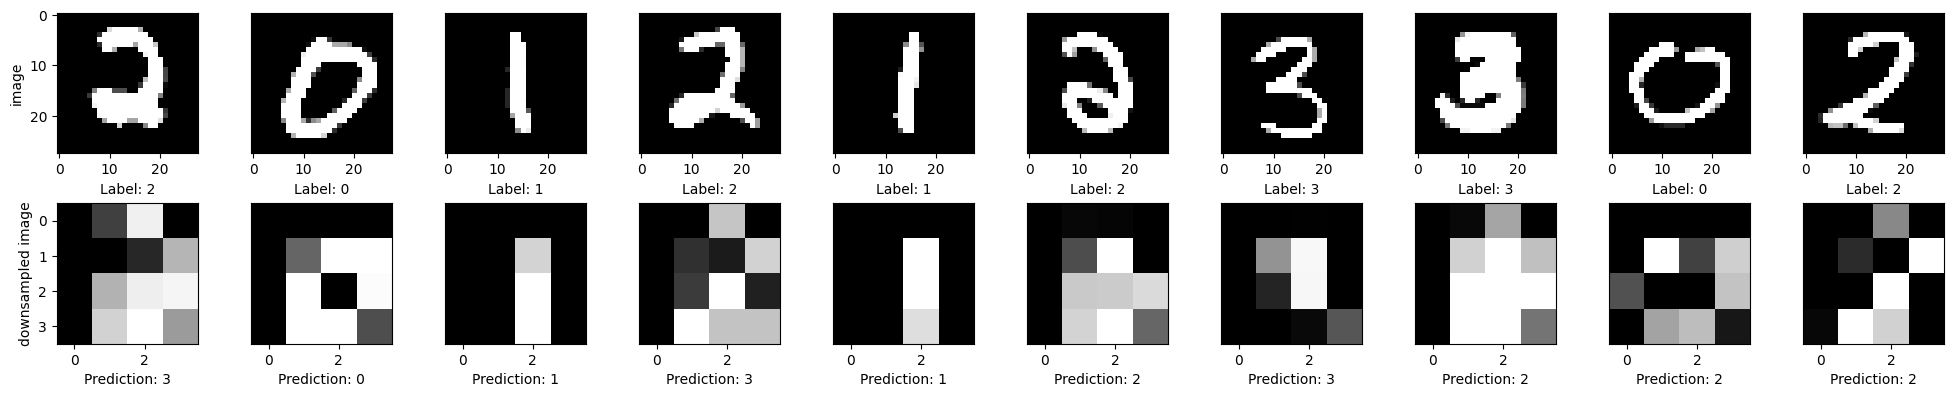

In [45]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
n_samples = 10
for feed_dict in dataflow['test']:
  inputs = feed_dict['image']
  outputs = feed_dict['digit']
  break
images = inputs[:n_samples]
# Down sample the image from 28x28 to 4x4.
# This down sampled image is the circuit input.
after_down_sample = F.avg_pool2d(images, 6)

# Forward the model to get prediction.
pred = model(images)
_, indices = pred.topk(1, dim=1)

# Plot 10 samples with label and prediction.
fig, axes = plt.subplots(2, n_samples, figsize=(20, 4))
for k in range(n_samples):
    axes[0, 0].set_ylabel("image")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].set_xlabel("Label: {0}".format(outputs[k]))
    norm = matplotlib.colors.Normalize(vmin=0, vmax=1)
    axes[0, k].imshow(images[k, 0, :, :].cpu(), norm=norm, cmap="gray")

    axes[1, 0].set_ylabel("downsampled image")
    if k != 0:
        axes[1, k].yaxis.set_visible(False)
    axes[1, k].set_xlabel("Prediction: {0}".format(indices[k][0]))
    axes[1, k].imshow(after_down_sample[k, 0, :, :], norm=norm, cmap="gray")

plt.tight_layout()
plt.show()


Sampled gene: [4, 3, 4, 2, 1, 4, 3]
Circuit depth: 10
Architecture:


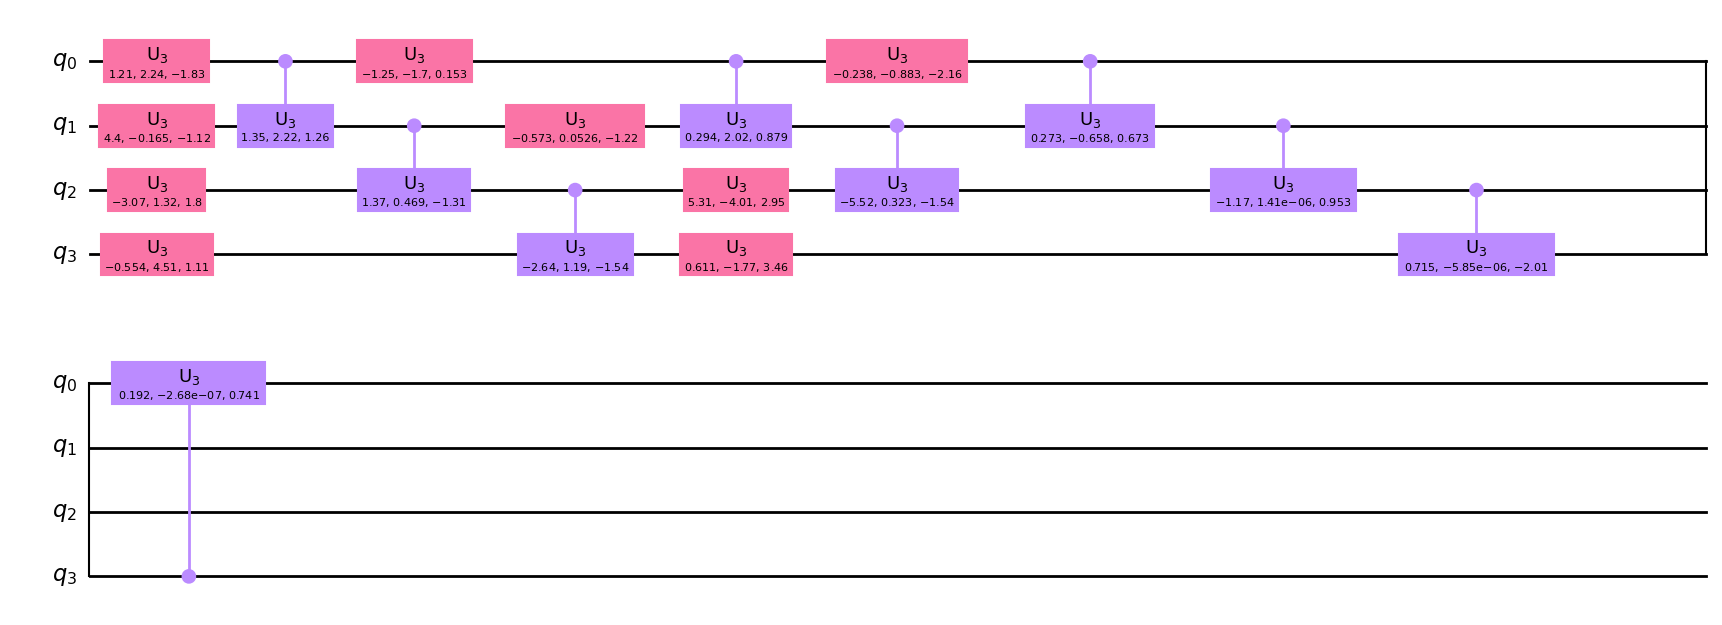

In [46]:
from torchquantum.plugins import tq2qiskit
gene_choice = model.arch_space
gene_len = len(gene_choice)
n_samples=1
samp_gene = []
for k in range(gene_len):
    samp_gene.append(random.choices(gene_choice[k])[0])
print("Sampled gene: " + str(samp_gene))
model.set_sample_arch(samp_gene)
circ = tq2qiskit(tq.QuantumDevice(n_wires=model.n_wires), model.q_layer)
print("Circuit depth: {0}".format(circ.depth()))
print("Architecture:")
circ.draw('mpl')

In [47]:
from torchquantum.plugins import QiskitProcessor

# Pure local simulation: no IBM Quantum account or remote backend required.
processor_simulation = QiskitProcessor(use_real_qc=False)

processor_simulation.set_layout([0, 1, 2, 3]) # default layout: virtual qubit 0 for physical qubit 0, ..., virtual qubit 3 for physical qubit 3

model.set_qiskit_processor(processor_simulation)

100%|██████████| 2/2 [00:00<00:00, 15.14it/s]
[2026-03-10 12:26:19.692] Accuracy: 0.49666666666666665
[2026-03-10 12:26:19.693] Loss: 1.2080745697021484
100%|██████████| 256/256 [00:01<00:00, 205.31it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 218.93it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run

Job Status: job has successfully run


100%|██████████| 2/2 [00:08<00:00,  4.26s/it]
[2026-03-10 12:26:28.220] Accuracy: 0.5033333333333333
[2026-03-10 12:26:28.220] Loss: 1.2077496911022354
100%|██████████| 2/2 [00:00<00:00, 15.37it/s]
[2026-03-10 12:26:28.352] Accuracy: 0.5466666666666666
[2026-03-10 12:26:28.352] Loss: 1.1071999073028564
100%|██████████| 256/256 [00:01<00:00, 152.77it/s]


...

100%|██████████| 2/2 [00:09<00:00,  4.68s/it]
[2026-03-10 12:26:37.722] Accuracy: 0.5466666666666666
[2026-03-10 12:26:37.723] Loss: 1.1076669206451788
100%|██████████| 2/2 [00:00<00:00, 13.54it/s]
[2026-03-10 12:26:37.873] Accuracy: 0.7133333333333334
[2026-03-10 12:26:37.874] Loss: 1.067213535308838
100%|██████████| 256/256 [00:02<00:00, 123.55it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 120.98it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 2/2 [00:09<00:00,  4.91s/it]
[2026-03-10 12:26:47.687] Accuracy: 0.7133333333333334
[2026-03-10 12:26:47.689] Loss: 1.0667793871676932


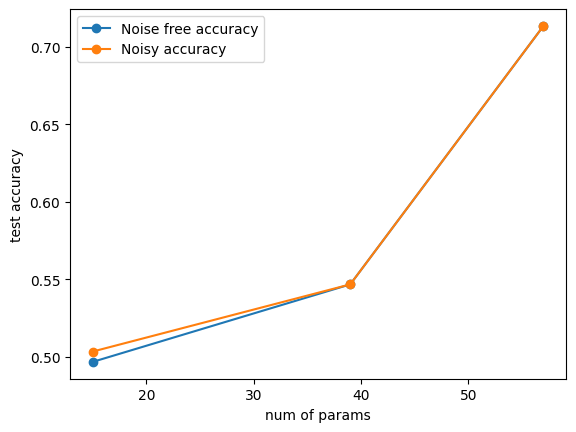

In [48]:
gene_list = [[3,2,4,4,2,4,1], [3,2,4,4,2,4,2], [3,2,4,4,2,4,3]]
param_num = []
accu_noise_free = []
accu_noisy_model = []
for gene in gene_list:
    total_params = 3 * sum(gene[k] for k in range(2 * gene[-1]))
    param_num.append(total_params)
    accu_noise_free.append(evaluate_gene(gene=gene, use_qiskit=False))
    accu_noisy_model.append(evaluate_gene(gene=gene, use_qiskit=True))

plt.plot(param_num, accu_noise_free, marker='o', label="Noise free accuracy")
plt.plot(param_num, accu_noisy_model, marker='o', label="Noisy accuracy")
plt.ylabel("test accuracy")
plt.xlabel("num of params")
plt.legend()
plt.show()

In [49]:
class RandomSearcher:
    def __init__(self, gene_choice, accuracy_predictor):
        self.gene_choice = gene_choice
        self.gene_len = len(self.gene_choice)
        self.accuracy_predictor = accuracy_predictor

    def random_sample(self, sample_num):
        # randomly sample genes
        population = []
        i = 0
        while i < sample_num:
            samp_gene = []
            for k in range(self.gene_len):
                samp_gene.append(random.choices(self.gene_choice[k])[0])
            population.append(samp_gene)
            i += 1

        return population

    def run_search(self, n_subcircuits=100):
        # sample subcircuits
        self.population = self.random_sample(n_subcircuits)
        # predict the accuracy of subnets
        accs = []
        for gene in self.population:
          accs.append(self.accuracy_predictor(gene=gene, use_qiskit=True))


        # get the index of the best subnet
        accs = np.array(accs)
        best_idx = accs.argmax()

        # return the best subnet
        return accs[best_idx], self.population[best_idx]

In [50]:
agent = RandomSearcher(model.arch_space, evaluate_gene)

# get the accuracy and gene of the best subcircuit
acc, gene = agent.run_search(10)

print(gene)
print(acc)

100%|██████████| 256/256 [00:01<00:00, 144.82it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 150.00it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 2/2 [00:09<00:00,  4.85s/it]
[2026-03-10 12:26:57.459] Accuracy: 0.6066666666666667
[2026-03-10 12:26:57.460] Loss: 1.0609526225472137
100%|██████████| 256/256 [00:01<00:00, 170.71it/s]


...

Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 218.33it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 2/2 [00:08<00:00,  4.27s/it]
[2026-03-10 12:28:18.061] Accuracy: 0.46
[2026-03-10 12:28:18.062] Loss: 1.3033725128622162


[3, 1, 2, 3, 4, 1, 2]
0.6566666666666666


In [51]:
class EvolutionarySearcher:
    def __init__(self,
                 gene_choice,
                 accuracy_predictor,
                 configs,
                 n_iter):
        self.gene_choice = gene_choice
        self.gene_len = len(self.gene_choice)
        self.accuracy_predictor = accuracy_predictor
        self.n_iterations = n_iter
        self.parent_size = 2 #configs.es.parent_size
        self.mutation_size = 4 #configs.es.mutation_size
        self.mutation_prob = configs.es.mutation_prob
        self.crossover_size = 4 #configs.es.crossover_size

    def random_sample(self, sample_num):
        # randomly sample genes
        population = []
        i = 0
        while i < sample_num:
            samp_gene = []
            for k in range(self.gene_len):
                samp_gene.append(random.choices(self.gene_choice[k])[0])
            population.append(samp_gene)
            i += 1
        return population

    def ask(self):
        """return the solutions"""
        return self.population

    def select_and_transform(self, scores):
        """perform evo search according to the scores"""

        # sort the index according to the scores (descending order)
        sorted_idx = (-np.array(scores)).argsort()[:self.parent_size]

        # hint: update self.best_solution and self.best_score
        self.best_solution = self.population[sorted_idx[0]]
        self.best_score = scores[sorted_idx[0]]

        parents = [self.population[i] for i in sorted_idx]

        # mutation
        mutate_population = []
        k = 0
        while k < self.mutation_size:
            mutated_gene = self.mutate(random.choices(parents)[0])
            mutate_population.append(mutated_gene)
            k += 1

        # crossover
        crossover_population = []
        k = 0
        while k < self.crossover_size:
            crossovered_gene = self.crossover(random.sample(parents, 2))
            crossover_population.append(crossovered_gene)
            k += 1

        self.population = parents + mutate_population + crossover_population

    def crossover(self, genes):
        crossovered_gene = []
        for i in range(self.gene_len):
            if np.random.uniform() < 0.5:
                crossovered_gene.append(genes[0][i])
            else:
                crossovered_gene.append(genes[1][i])
        return crossovered_gene

    def mutate(self, gene):
        mutated_gene = []
        for i in range(self.gene_len):
            # use np.random.uniform() to decide whether to mutate position i
            # mutate ith position of gene with self.mutation_prob as mutation probability
            if np.random.uniform() < self.mutation_prob:
                mutated_gene.append(random.choices(self.gene_choice[i])[0])
            else:
                mutated_gene.append(gene[i])
        return mutated_gene

    def run_search(self):
        # sample subcircuits
        self.population = self.random_sample(self.parent_size + self.mutation_size + self.crossover_size)
        for i in range(self.n_iterations):
            # predict the accuracy of subnets
            accs = []
            for gene in self.population:
                accs.append(self.accuracy_predictor(gene=gene, use_qiskit=True))
            self.select_and_transform(accs)
            logger.info(f"Best solution: {self.best_solution}")
            logger.info(f"Best score: {self.best_score}")
        # return the best subnet
        return self.best_score, self.best_solution

In [52]:
agent2 = EvolutionarySearcher(model.arch_space, evaluate_gene, configs, 3)

# get the accuracy and gene of the best subcircuit
acc, gene = agent2.run_search()

print(gene)
print(acc)

100%|██████████| 256/256 [00:01<00:00, 216.64it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 211.38it/s]


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 2/2 [00:08<00:00,  4.35s/it]
[2026-03-10 12:28:26.776] Accuracy: 0.47
[2026-03-10 12:28:26.777] Loss: 1.1957201275521676
100%|██████████| 256/256 [00:01<00:00, 128.93it/s]


...

Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 44/44 [00:00<00:00, 166.09it/s]


Job Status: job has successfully run


Job Status: job has successfully run
Job Status: job has successfully run
Job Status: job has successfully run


100%|██████████| 2/2 [00:09<00:00,  4.61s/it]
[2026-03-10 12:32:49.587] Accuracy: 0.6466666666666666
[2026-03-10 12:32:49.587] Loss: 1.0700757693966059
[2026-03-10 12:32:49.588] Best solution: [4, 1, 3, 3, 1, 2, 2]
[2026-03-10 12:32:49.588] Best score: 0.68


[4, 1, 3, 3, 1, 2, 2]
0.68


Circuit depth: 6
Gate counts: OrderedDict([('u3', 7), ('cu3', 4)])
Architecture:


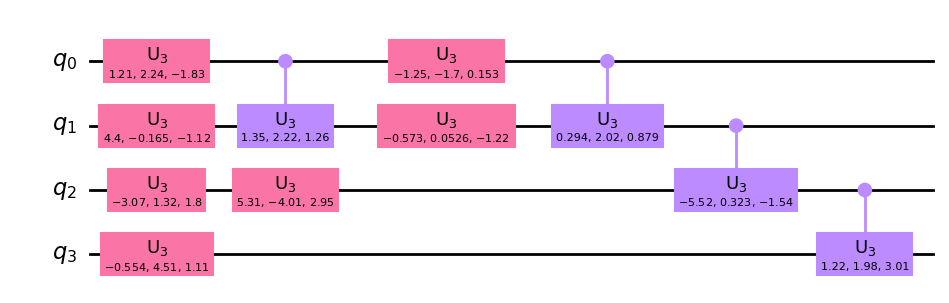

In [53]:
model.set_sample_arch(gene)
circ = tq2qiskit(tq.QuantumDevice(n_wires=model.n_wires), model.q_layer)
print("Circuit depth: {0}".format(circ.depth()))
print("Gate counts: {0}".format(circ.count_ops()))
print("Architecture:")
circ.draw('mpl')

In [54]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [55]:
def mod_pi(x):
    while x > np.pi:
        x = x - 2 * np.pi
    while x < -np.pi:
        x = x + 2 * np.pi
    return x

params_before_prune = []
for param in model.parameters():
    for x in param.reshape(-1):
        params_before_prune.append(mod_pi(x.cpu().detach().numpy()))

In [56]:
print(params_before_prune)

[array(1.2060113, dtype=float32), array(2.2385259, dtype=float32), array(-1.831825, dtype=float32), -1.8875616232501429, array(-0.16537467, dtype=float32), array(-1.1199452, dtype=float32), array(-3.0714889, dtype=float32), array(1.319183, dtype=float32), array(1.8012493, dtype=float32), array(-0.55449617, dtype=float32), -1.776839558278219, array(1.1050001, dtype=float32), array(1.3458017, dtype=float32), array(2.2216663, dtype=float32), array(1.2591805, dtype=float32), array(1.3722651, dtype=float32), array(0.46867403, dtype=float32), array(-1.3104833, dtype=float32), array(-2.6374984, dtype=float32), array(1.1927967, dtype=float32), array(-1.537862, dtype=float32), array(-0.961351, dtype=float32), array(-0.6752364, dtype=float32), array(0.6030566, dtype=float32), array(-1.2493807, dtype=float32), array(-1.7007474, dtype=float32), array(0.1528023, dtype=float32), array(-0.5733373, dtype=float32), array(0.05264929, dtype=float32), array(-1.218637, dtype=float32), -0.9736960569964808, 

In [57]:
import torch.nn as nn
import torch.nn.utils.prune
# from torchquantum.prune_utils import (PhaseL1UnstructuredPruningMethod,
#                                       ThresholdScheduler)
from torchpack.train import Trainer
from torchpack.utils.typing import Optimizer, Scheduler
from torchpack.callbacks.writers import TFEventWriter
from typing import Any, Callable, Dict

class PruningTrainer(Trainer):
    """
    Perform pruning-aware training
    """
    def __init__(self, *, model: nn.Module, criterion: Callable,
                 optimizer: Optimizer, scheduler: Scheduler) -> None:
        self.model = model
        self.legalized_model = None
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.solution = None
        self.score = None

        self._parameters_to_prune = None
        self._target_pruning_amount = None
        self._init_pruning_amount = None
        self.prune_amount_scheduler = None
        self.prune_amount = None

        self.init_pruning()

    @staticmethod
    def extract_prunable_parameters(model: nn.Module) -> list:
        _parameters_to_prune = [
            (module, "params")
            for _, module in model.named_modules() if isinstance(module,
                                                                 tq.Operator)
            and module.params is not None]
        return _parameters_to_prune

    def init_pruning(self) -> None:
        """
        Initialize pruning procedure
        """
        self._parameters_to_prune = self.extract_prunable_parameters(
            self.model)
        self._target_pruning_amount = configs.prune.target_pruning_amount
        self._init_pruning_amount = configs.prune.init_pruning_amount
        self.prune_amount_scheduler = ThresholdScheduler(
            configs.prune.start_epoch, configs.prune.end_epoch,
            self._init_pruning_amount,
            self._target_pruning_amount)
        self.prune_amount = self._init_pruning_amount

    def _remove_pruning(self):
        for module, name in self._parameters_to_prune:
            nn.utils.prune.remove(module, name)

    def _prune_model(self, prune_amount) -> None:
        """
        Perform global threshold/percentage pruning on the quantum model.
        This function just performs pruning re-parametrization, i.e.,
        record weight_orig and generate weight_mask
        """
        # first clear current pruning container, since we do not want cascaded
        # pruning methods
        # remove operation will make pruning permanent
        if self.epoch_num > 1:
            self._remove_pruning()
        # perform global phase pruning based on the given pruning amount
        nn.utils.prune.global_unstructured(
            self._parameters_to_prune,
            pruning_method=PhaseL1UnstructuredPruningMethod,
            amount=prune_amount,
        )
        self.summary.add_scalar('prune_amount', prune_amount)

    def _before_epoch(self) -> None:
        self.model.train()

    def run_step(self, feed_dict: Dict[str, Any], legalize=False) -> Dict[str, Any]:
        output_dict = self._run_step(feed_dict, legalize=legalize)
        return output_dict

    def _run_step(self, feed_dict: Dict[str, Any], legalize=False) -> Dict[str, Any]:
        if configs.run.device == 'gpu':
            inputs = feed_dict[configs.dataset.input_name].cuda(
                non_blocking=True)
            targets = feed_dict[configs.dataset.target_name].cuda(
                non_blocking=True)
        else:
            inputs = feed_dict[configs.dataset.input_name]
            targets = feed_dict[configs.dataset.target_name]
        if legalize:
            outputs = self.legalized_model(inputs)
        else:
            outputs = self.model(inputs)
        loss = self.criterion(outputs, targets)
        nll_loss = loss.item()
        unitary_loss = 0

        if loss.requires_grad:
            for k, group in enumerate(self.optimizer.param_groups):
                self.summary.add_scalar(f'lr/lr_group{k}', group['lr'])

            self.summary.add_scalar('loss', loss.item())
            self.summary.add_scalar('nll_loss', nll_loss)
            if getattr(self.model, 'sample_arch', None) is not None:
                for writer in self.summary.writers:
                    if isinstance(writer, TFEventWriter):
                        writer.writer.add_text(
                            'sample_arch', str(self.model.sample_arch),
                            self.global_step)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        return {'outputs': outputs, 'targets': targets}

    def _after_epoch(self) -> None:
        self.model.eval()
        self.scheduler.step()
        # update pruning amount using the scheduler
        self.prune_amount = self.prune_amount_scheduler.step()
        # prune the model
        self._prune_model(self.prune_amount)
        # commit pruned parameters after training
        if self.epoch_num == self.num_epochs:
            self._remove_pruning()

    def _after_step(self, output_dict) -> None:
        pass

    def _state_dict(self) -> Dict[str, Any]:
        state_dict = dict()
        # need to store model arch because of randomness of random layers
        state_dict['model_arch'] = self.model
        state_dict['model'] = self.model.state_dict()
        state_dict['optimizer'] = self.optimizer.state_dict()
        state_dict['scheduler'] = self.scheduler.state_dict()
        if getattr(self.model, 'sample_arch', None) is not None:
            state_dict['sample_arch'] = self.model.sample_arch
        try:
            state_dict['q_layer_op_list'] = build_module_op_list(
                self.model.q_layer)
            state_dict['encoder_func_list'] = self.model.encoder.func_list
        except AttributeError:
            logger.warning(f"No q_layer_op_list or encoder_func_list found, "
                           f"will not save them")

        if self.solution is not None:
            state_dict['solution'] = self.solution
            state_dict['score'] = self.score

        try:
            state_dict['v_c_reg_mapping'] = self.model.measure.v_c_reg_mapping
        except AttributeError:
            logger.warning(f"No v_c_reg_mapping found, will not save it.")
        return state_dict

    def _load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        # self.model.load_state_dict(state_dict['model'])
        self.optimizer.load_state_dict(state_dict['optimizer'])
        self.scheduler.load_state_dict(state_dict['scheduler'])


In [58]:
from torchpack.callbacks import (InferenceRunner, MaxSaver, Saver, CategoricalAccuracy)
from examples.gradient_pruning.callbacks import NLLError

def get_subcallbacks(config):
    subcallbacks = []
    for subcallback in config:
        if subcallback['metrics'] == 'CategoricalAccuracy':
            subcallbacks.append(
                CategoricalAccuracy(name=subcallback['name'])
            )
        elif subcallback['metrics'] == 'NLLError':
            subcallbacks.append(
                NLLError(name=subcallback['name'])
            )
        else:
            raise NotImplementedError(subcallback['metrics'])
    return subcallbacks


def make_callbacks(dataflow):
    callbacks = []
    for config in configs['callbacks']:
        if config['callback'] == 'InferenceRunner':
            callback = InferenceRunner(
                dataflow=dataflow[config['split']],
                callbacks=get_subcallbacks(config['subcallbacks'])
            )
        elif config['callback'] == 'Saver':
            callback = Saver(max_to_keep=config['max_to_keep'])
        elif config['callback'] == 'MaxSaver':
            callback = MaxSaver(config['name'])
        else:
            raise NotImplementedError(config['callback'])
        callbacks.append(callback)

    return callbacks


In [59]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Reset the pruning ratio here
configs.prune.target_pruning_amout = 0.5
n_finetune_epochs = 10

model2 = SuperQFCModel0(configs.model.arch)
checkpoint = torch.load('max-acc-valid.pt', map_location='cpu', weights_only=False)
model2.load_state_dict(checkpoint['model'], strict=False)
model2.to(device)
model2.set_sample_arch(gene)


if isinstance(configs.optimizer.lr, str):
    configs.optimizer.lr = eval(configs.optimizer.lr)
if isinstance(configs.optimizer.weight_decay, str):
    configs.optimizer.weight_decay = eval(configs.optimizer.weight_decay)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=configs.optimizer.lr,
    weight_decay=configs.optimizer.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=configs.run.n_epochs)
trainer = PruningTrainer(model=model2,
                    criterion=criterion,
                    optimizer=optimizer,
                    scheduler=scheduler)
run_dir = 'runs/quantumnas/'
set_run_dir(run_dir)
logger.info(' '.join([sys.executable] + sys.argv))
logger.info(f'Pruning started: "{run_dir}".' + '\n' +f'{configs}')
callbacks = make_callbacks(dataflow)
trainer.train_with_defaults(
    dataflow['train'],
    num_epochs=n_finetune_epochs,
    callbacks=callbacks)
from torch.optim.lr_scheduler import CosineAnnealingLR

# Reset the pruning ratio here
configs.prune.target_pruning_amout = 0.5
n_finetune_epochs = 10

model2 = SuperQFCModel0(configs.model.arch)
checkpoint = torch.load('max-acc-valid.pt', map_location='cpu', weights_only=False)
model2.load_state_dict(checkpoint['model'], strict=False)
model2.to(device)
model2.set_sample_arch(gene)


if isinstance(configs.optimizer.lr, str):
    configs.optimizer.lr = eval(configs.optimizer.lr)
if isinstance(configs.optimizer.weight_decay, str):
    configs.optimizer.weight_decay = eval(configs.optimizer.weight_decay)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=configs.optimizer.lr,
    weight_decay=configs.optimizer.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=configs.run.n_epochs)
trainer = PruningTrainer(model=model2,
                    criterion=criterion,
                    optimizer=optimizer,
                    scheduler=scheduler)
run_dir = 'runs/quantumnas/'
set_run_dir(run_dir)
logger.info(' '.join([sys.executable] + sys.argv))
logger.info(f'Pruning started: "{run_dir}".' + '\n' +f'{configs}')
callbacks = make_callbacks(dataflow)
trainer.train_with_defaults(
    dataflow['train'],
    num_epochs=n_finetune_epochs,
    callbacks=callbacks)


[2026-03-10 12:32:49.746] /home/changhong/anaconda3/envs/qnas_py39/bin/python /home/changhong/anaconda3/envs/qnas_py39/lib/python3.9/site-packages/ipykernel_launcher.py --f=/run/user/1000/jupyter/runtime/kernel-v3e8f0030baa593096806c2345958611e0e2dc7999.json
[2026-03-10 12:32:49.746] Pruning started: "runs/quantumnas/".
model:
  arch:
    n_wires: 4
    encoder_op_list_name: 4x4_ryzxy
    n_blocks: 3
    n_layers_per_block: 2
    q_layer_name: u3cu3_s0
    down_sample_kernel_size: 6
    n_front_share_blocks: 1
    n_front_share_wires: 1
    n_front_share_ops: 1
  sampler:
    strategy:
      name: plain
  transpile_before_run: False
  load_op_list: False
dataset:
  name: mnist
  input_name: image
  target_name: digit
optimizer:
  name: adam
  lr: 0.05
  weight_decay: 0.0001
  lambda_lr: 1e-2
run:
  n_epochs: 40
  bsz: 256
  workers_per_gpu: 2
  device: gpu
debug:
  pdb: False
  set_seed: True
  seed: 42
callbacks: [{'callback': 'InferenceRunner', 'split': 'valid', 'subcallbacks': [{'me

In [60]:
params_after_prune = []
for param in model2.parameters():
    for x in param.reshape(-1):
        params_after_prune.append(mod_pi(x.cpu().detach().numpy()))

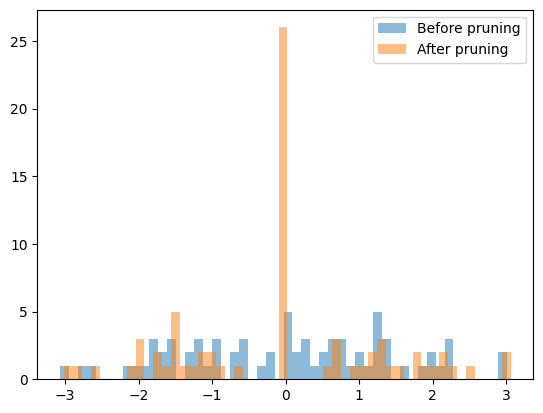

In [61]:
plt.hist(params_before_prune, bins=50, alpha=0.5, label='Before pruning')
plt.hist(params_after_prune, bins=50, alpha=0.5, label='After pruning')
plt.legend()
plt.show()

Circuit depth: 6
Architecture:


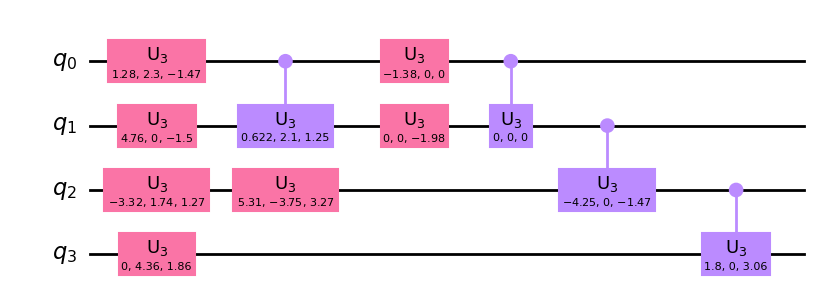

In [62]:
circ = tq2qiskit(tq.QuantumDevice(n_wires=model.n_wires), model2.q_layer)
print("Circuit depth: {0}".format(circ.depth()))
print("Architecture:")
circ.draw('mpl')
